# Predictive Maintenance - NASA C-MAPSS (Random Forest)
This project is inspired by Honeywell's predictive maintenance problem.
The goal is to predict engine failures in advance using multiple sensor readings.
We approach this by predicting the Remaining Useful Life (RUL).

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import os

# import our helper functions
from utils import calculate_rmse, calculate_mae, drop_constant_columns, remove_highly_correlated_features

# suppress warnings to keep the notebook clean
import warnings
warnings.filterwarnings('ignore')

### 2. Load Data

In [2]:
# using multiple sensor readings for prediction
# Set column names
columns = ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

# Read the files from the dataset folder
train_data = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None, names=columns)
test_data = pd.read_csv('dataset/test_FD001.txt', sep='\s+', header=None, names=columns)
rul_data = pd.read_csv('dataset/RUL_FD001.txt', sep='\s+', header=None, names=['RUL_actual'])

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (20631, 26)
Testing data shape: (13096, 26)


### 3. RUL Calculation
For the train data, the Remaining Useful Life (RUL) is the max cycle minus the current cycle.
For the test data, the true RUL is provided only for the last cycle of each engine in `RUL_FD001.txt`.

In [3]:
# Calculate RUL for training data
train_max = train_data.groupby('unit')['cycle'].max().reset_index()
train_max.columns = ['unit', 'max_cycle']
train_data = train_data.merge(train_max, on='unit', how='left')
train_data['RUL'] = train_data['max_cycle'] - train_data['cycle']

# Calculate RUL for testing data
rul_data['unit'] = rul_data.index + 1
test_max = test_data.groupby('unit')['cycle'].max().reset_index()
test_max.columns = ['unit', 'max_cycle']
test_data = test_data.merge(test_max, on='unit', how='left')
test_data = test_data.merge(rul_data, on='unit', how='left')

# The actual RUL at any given cycle in the test set
test_data['RUL'] = test_data['RUL_actual'] + (test_data['max_cycle'] - test_data['cycle'])

# drop the extra target column
test_data.drop(columns=['RUL_actual'], inplace=True)

### 4. Feature Engineering
We will add a normalized cycle feature and a rolling mean for the sensors with a window of 5.

In [4]:
# normalized cycle feature
train_data['norm_cycle'] = train_data['cycle'] / train_data['max_cycle']
test_data['norm_cycle'] = test_data['cycle'] / test_data['max_cycle']

# get all the sensor column names
sensors = [f'sensor_{i}' for i in range(1, 22)]

# calculate rolling means
train_roll = train_data.groupby('unit')[sensors].rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)
test_roll = test_data.groupby('unit')[sensors].rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)

# rename the rolling columns
train_roll.columns = [f'{s}_roll' for s in sensors]
test_roll.columns = [f'{s}_roll' for s in sensors]

# add them back to the original dataframes
train_data = pd.concat([train_data, train_roll], axis=1)
test_data = pd.concat([test_data, test_roll], axis=1)
# combining features from different sensors (feature fusion)

### 5. Data Cleaning
We use our helper functions from `utils.py` to drop constant columns and highly correlated features so the model doesn't overfit to redundant data.

In [5]:
# Drop constant columns
train_data, test_data = drop_constant_columns(train_data, test_data)

# Drop highly correlated columns
exclude_from_corr = ['unit', 'cycle', 'max_cycle', 'RUL']
train_data, test_data = remove_highly_correlated_features(train_data, test_data, exclude_from_corr)

### 6. Feature Scaling
Scaling is important. We fit the scaler on the training data only.

In [6]:
# Get the final list of features we will use for training
final_features = [c for c in train_data.columns if c not in exclude_from_corr]

# scale the features
scaler = StandardScaler()
train_data[final_features] = scaler.fit_transform(train_data[final_features])
test_data[final_features] = scaler.transform(test_data[final_features])

# prepare X and y
X_train = train_data[final_features]
y_train = train_data['RUL']
X_test = test_data[final_features]
y_test = test_data['RUL']

### 7. Baseline
Let's make a simple baseline by just predicting the mean RUL of the training set.

In [7]:
mean_rul = y_train.mean()
baseline_preds = np.full_like(y_test, fill_value=mean_rul)

baseline_rmse = calculate_rmse(y_test, baseline_preds)
baseline_mae = calculate_mae(y_test, baseline_preds)

print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline MAE:", round(baseline_mae, 2))

Baseline RMSE: 68.2
Baseline MAE: 54.48


### 8. Model Training
Now we train the Random Forest Regressor model.
We use Random Forest as our baseline model.

In [8]:
rf_model = RandomForestRegressor(
    random_state=42, 
    n_estimators=100, 
    max_depth=10,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### 9. Evaluation
Let's see how our Random Forest model performed compared to the baseline.

In [9]:
# predicting RUL to estimate failure in advance
y_pred = rf_model.predict(X_test)

rf_rmse = calculate_rmse(y_test, y_pred)
rf_mae = calculate_mae(y_test, y_pred)

print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest MAE:", round(rf_mae, 2))

Random Forest RMSE: 54.35
Random Forest MAE: 42.28


### 10. Visualization
Plotting the actual vs predicted RUL for the last cycle of each engine.

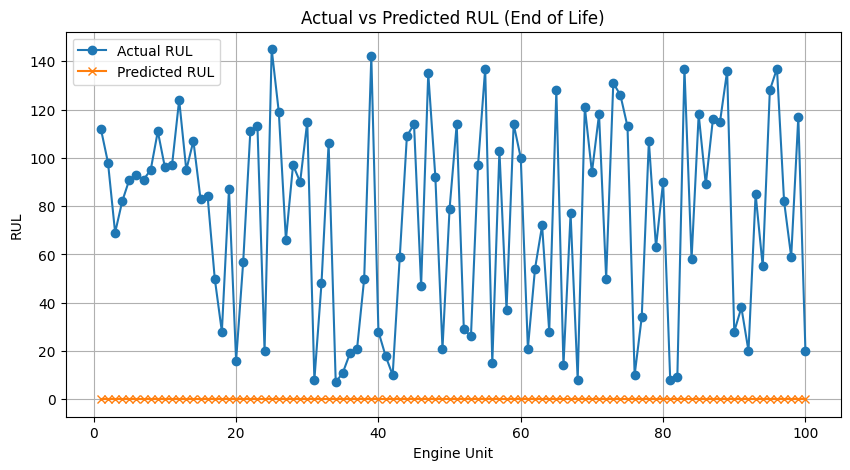

In [10]:
# add predictions back to group by unit
test_data['predicted_RUL'] = y_pred

# get the last cycle for each engine
last_cycles = test_data.groupby('unit').last()

# plot the results
plt.figure(figsize=(10, 5))
plt.plot(last_cycles.index, last_cycles['RUL'], label='Actual RUL', marker='o')
plt.plot(last_cycles.index, last_cycles['predicted_RUL'], label='Predicted RUL', marker='x')

plt.title('Actual vs Predicted RUL (End of Life)')
plt.xlabel('Engine Unit')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)

# make sure results folder exists and save plot
os.makedirs('results', exist_ok=True)
plt.savefig('results/rf_actual_vs_predicted.png')
plt.show()

## 11. Classification Evaluation (Additional)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Convert y_test and y_pred to binary values
# If RUL < 30 -> 1 (failure soon)
# Else -> 0
y_test_binary = [1 if y < 30 else 0 for y in y_test]
y_pred_binary = [1 if y < 30 else 0 for y in y_pred]

# Compute classification metrics
conf_matrix = confusion_matrix(y_test_binary, y_pred_binary)
accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)

# Print the results clearly
print("Classification Evaluation Results:")
print("----------------------------------")
print("Confusion Matrix:")
print(conf_matrix)
print("Accuracy Score: ", accuracy)
print("Precision Score:", precision)
print("Recall Score:   ", recall)
print("F1 Score:       ", f1)
